## Paso 1 — Cargar el dataset

### 1.1 Cargar librerias

In [18]:
# Tratamiento de datos
import numpy as np
import pandas as pd
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


### 1.2 Cargar dataset

In [44]:
df = pd.read_csv('mpg.csv')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    398 non-null    int64  
 1   mpg           398 non-null    float64
 2   cylinders     398 non-null    int64  
 3   displacement  398 non-null    float64
 4   horsepower    392 non-null    float64
 5   weight        398 non-null    int64  
 6   acceleration  398 non-null    float64
 7   model_year    398 non-null    int64  
 8   origin        398 non-null    object 
 9   name          398 non-null    object 
dtypes: float64(4), int64(4), object(2)
memory usage: 31.2+ KB


Hay datos que no son numericos por lo que deben transformarse para poder utilizarlos en el modelo. Ademas, la columna horsepower tiene 392 valores, pero al haber 398 entradas totales muestra que hay 6 valores nulos. Tambien considero que se puede eliminar la columna "Unnamed: 0", ya que parece ser un indice y no aporta informacion relevante al analisis.

## Paso 2 — Exploración y análisis inicial de los datos

###  2.1 Verificar Nulls

In [45]:
df.isnull().sum()

,0
Unnamed: 0,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


Efectivamente horsepower tiene 6 valores nulos.

### 2.2  Limpieza y transformación de datos

In [46]:
# eliminar columna innecesaria
df = df.drop("Unnamed: 0", axis=1)

# corregir valores nulos
df["horsepower"] = df["horsepower"].fillna(
    df["horsepower"].mean()
)

# eliminar columna de texto irrelevante
df = df.drop("name", axis=1)

# aplicar One Hot Encoding
df = pd.get_dummies(
    df,
    columns=['origin'],
    drop_first=True
)

# convertir booleanos a enteros
df[['origin_japan', 'origin_usa']] = (
    df[['origin_japan', 'origin_usa']]
    .astype(int)
)


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin_japan  398 non-null    int64  
 8   origin_usa    398 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 28.1 KB


In [47]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin_japan,0
origin_usa,0


### 2.3 Estadísticas descriptivas

In [48]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,0.198492,0.625628
std,7.815984,1.701004,104.269838,38.199187,846.841774,2.757689,3.697627,0.399367,0.484569
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,0.000000,0.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,0.000000,0.000000
50%,23.000000,4.000000,148.500000,95.000000,2803.500000,15.500000,76.000000,0.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,0.000000,1.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,1.000000,1.000000


### 2.4 Histogramas

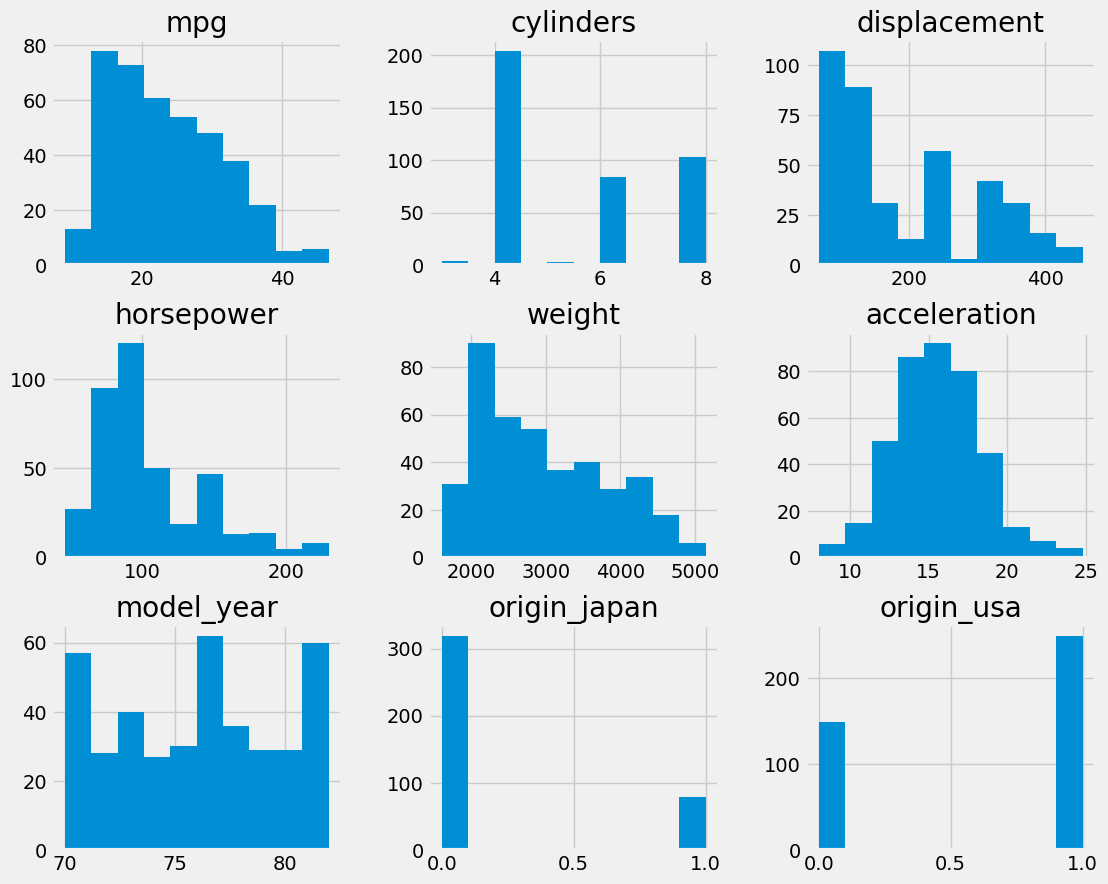

In [49]:
df.hist(figsize=(12,10))
plt.show()

### 2.5 Boxplots

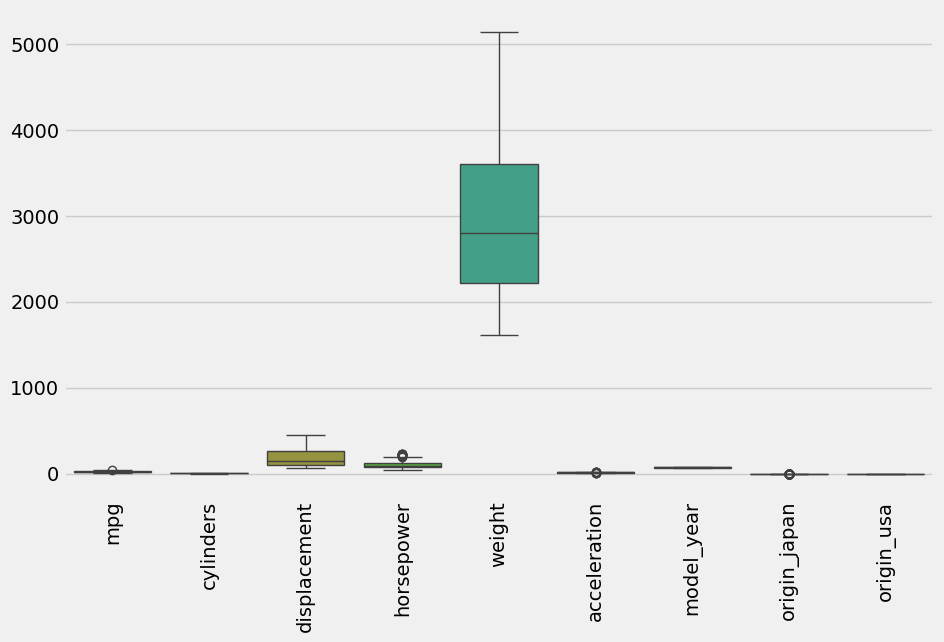

In [50]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

### 2.6 Matriz de correlación

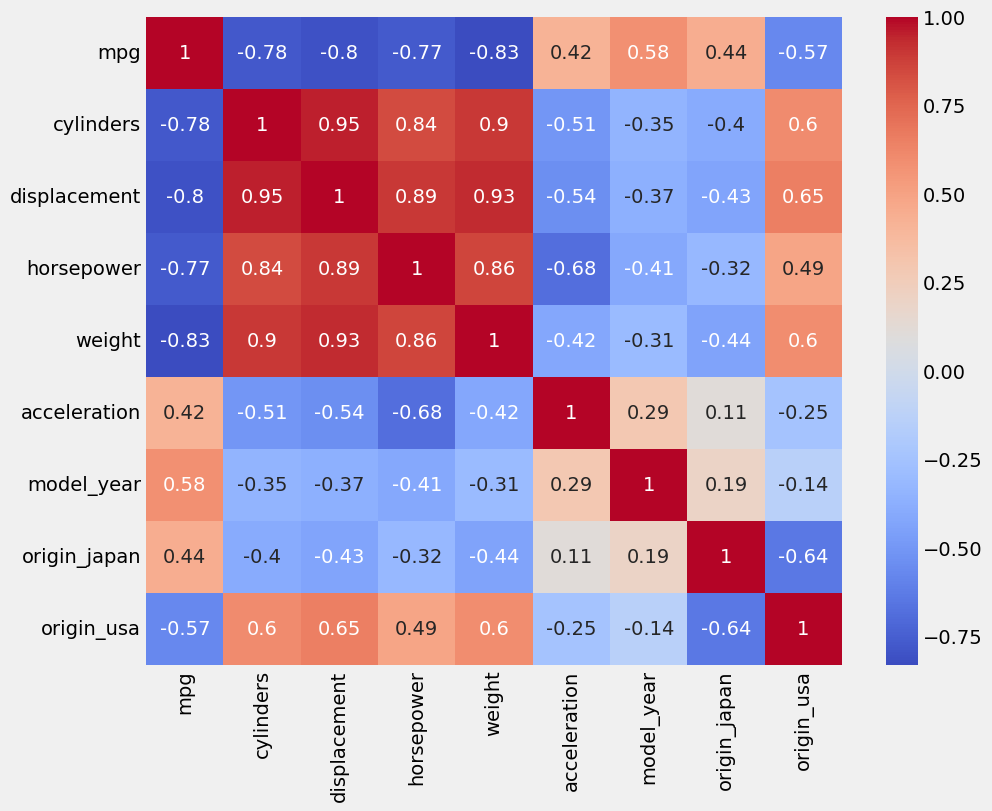

In [51]:
# crear matriz
corr = df.corr()
corr
plt.figure(figsize=(10,8))
sns.heatmap(
corr,
annot=True,
cmap="coolwarm")
plt.show()

La matriz de correlación muestra que las variables weight, displacement, cylinders y horsepower parecen ser fuertes candidatas para predecir la variable objetivo mpg, ya que presentan correlaciones altas en valor absoluto con dicha variable. Esto implica que los vehículos más grandes, pesados y potentes tienden a tener menor eficiencia de combustible.

Por otro lado, existe posible multicolinealidad entre algunas variables independientes, especialmente cylinders, displacement y weight, debido a que presentan correlaciones muy altas entre sí. Por lo tanto, será necesario verificar este problema al entrenar el modelo OLS.

### 2.7 Scatterplots

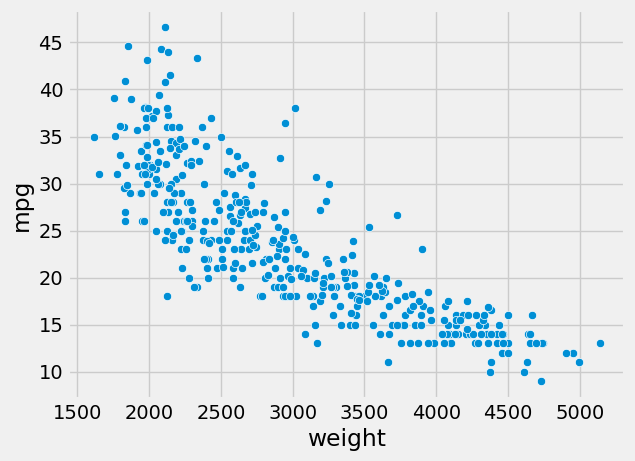

In [52]:
sns.scatterplot(
    x=df["weight"],
    y=df["mpg"]
)
plt.show()

EL grafico muestra una  relacion negativa casi lineal entre las variables weight y mpg. Es decir, q medida que aumenta el peso (weight) del vehículo, disminuye la eficiencia de combustible que se mide en millas por galón (mpg).

## Paso 3 — Definir variables predictoras y objetivo.

In [53]:
# Variables predictoras
X = df.drop("mpg", axis=1)

# Variable objetivo
y = df["mpg"]

## Paso 4 — Separar entrenamiento y prueba

In [54]:
# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Paso 5 — Agregar constante

In [55]:
# Agregar constante
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

## Paso 6 — Crear modelo OLS

In [56]:
modelo = sm.OLS(y_train, X_train)

## Paso 7 — Entrenar modelo

In [57]:
# Entrenar modelo
resultado = modelo.fit()

## Paso 8 — Ver resumen estadístico

In [58]:
# Ver resumen estadístico
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     174.6
Date:                Wed, 13 May 2026   Prob (F-statistic):          8.35e-110
Time:                        23:01:00   Log-Likelihood:                -837.59
No. Observations:                 318   AIC:                             1693.
Df Residuals:                     309   BIC:                             1727.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -19.1275      5.402     -3.541   

El modelo logro explicar aproximadamente el 81,9% de la variacion de mpg.

Sin embargo, algunas variables como cylinders, horsepower, acceleration y origin_japan no resultaron significativas dentro del modelo, ya que tenían p-values altos.

Además, existía multicolinealidad entre varias variables relacionadas con el tamaño y potencia del vehículo, como cylinders, displacement, horsepower y weight.

Por este motivo se decide eliminar las variables menos relevantes y trabajar con un modelo reducido mas estable y facil de interpretar

#### nuevo modelo reducido:

In [68]:
# Variables eliminadas del modelo
X = df.drop(
    ['mpg', 'cylinders', 'horsepower', 'acceleration', 'origin_japan'],
    axis=1
)

# Variable objetivo
y = df['mpg']

# Separacion train/test nuevamente
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Agregar constante
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Crear modelo nuevo
modelo_corregido = sm.OLS(
    y_train,
    X_train.astype(float)
)

# Entrenar el modelo
resultado_corregido = modelo_corregido.fit()

# Resumen
print(resultado_corregido.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     348.7
Date:                Thu, 14 May 2026   Prob (F-statistic):          6.04e-114
Time:                        00:01:58   Log-Likelihood:                -839.42
No. Observations:                 318   AIC:                             1689.
Df Residuals:                     313   BIC:                             1708.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -19.9871      4.605     -4.340   

Luego de entrenar el modelo reducido, se observo que la variable displacement presentaba un p-value de 0.059, valor ligeramente superior al umbral de significancia de 0.05. Se decidio probar un segundo modelo eliminando dicha variable para ver el comportamiento del modelo y evaluar si era posible simplificarlo aun mas sin perder capacidad predictiva.

#### nuevo modelo mas reducido aun:

In [80]:
# Variables predictoras finales
X = df.drop(
    ['mpg', 'cylinders', 'horsepower', 'acceleration', 'origin_japan', 'displacement'],
    axis=1
)

# Variable objetivo
y = df['mpg']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Agregar constante
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Modelo OLS
modelo = sm.OLS(y_train, X_train)

# Entrenamiento
resultado = modelo.fit()

# Resumen
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     460.0
Date:                Thu, 14 May 2026   Prob (F-statistic):          1.54e-114
Time:                        00:43:16   Log-Likelihood:                -841.23
No. Observations:                 318   AIC:                             1690.
Df Residuals:                     314   BIC:                             1706.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -18.7581      4.578     -4.097      0.0

Al eliminar las varaibles que no son significativas,  el modelo reducido mantiene un buen nivel de ajuste, explicando aproximadamente el 81,5% de la variacion de mpg.

## Paso 9 — Realizar predicciones

In [81]:
# Predicciones
y_pred = resultado.predict(X_test)

## Paso 10 — Evaluar el modelo

In [82]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE:", rmse)

RMSE: 2.944101454153933


Un RMSE de aproximadamente 2.94 significa que el modelo suele equivocarse, en promedio, alrededor de 2.94 mpg al realizar una predicción. Es decir, las predicciones pueden diferir cerca de “3 mpg” respecto a los valores reales.

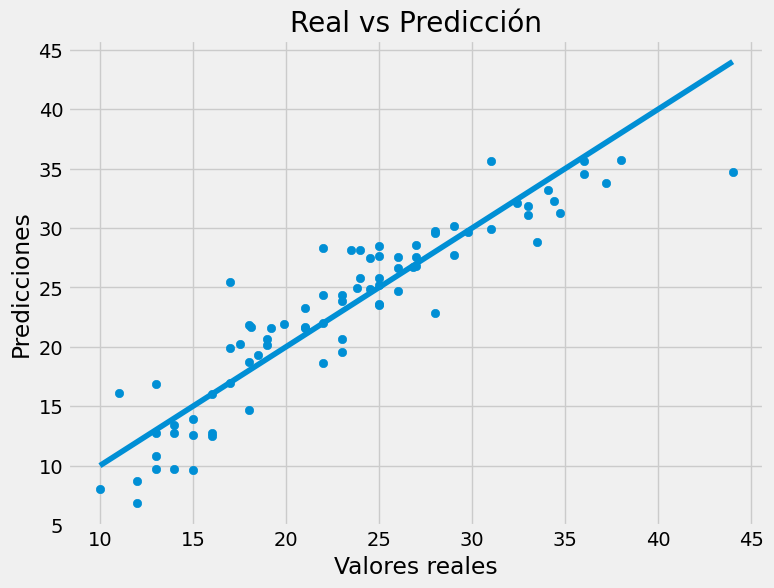

In [84]:
# Comparacion visual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
# linea diagonal ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicción")
plt.show()

El grafico se comparan los valores reales con las predicciones realizadas por el modelo. Idealmente, los puntos deberían acercarse a la linea diagonal, ya que eso indicaria que las predicciones coinciden con los valores reales. En este caso, muchos de los puntos se encuentran relativamente cerca de esa diagonal, lo que sugiere que el modelo logra realizar predicciones bastante precisas.

## Paso 11 — Analizar residuos

In [85]:
# calcular residuos
residuos = y_test - y_pred

## Paso 12 — Análisis gráfico de residuos

Scatterplot:

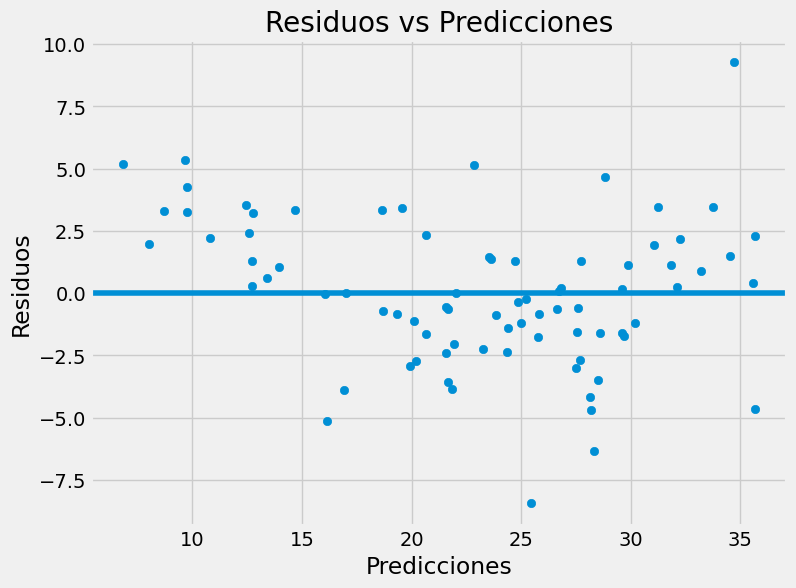

In [86]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuos)

plt.axhline(y=0)

plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos vs Predicciones")

plt.show()

Idealmente, los residuos deberian distribuirse de manera aleatoria alrededor de la linea horizontal en 0, sin formar patrones claros. Como en este caso, los residuos parecen dispersarse alrededor de 0 sin una tendencia marcada, pareceria que el modelo logra capturar en gran medida la relacion entre las variables.

Histograma:

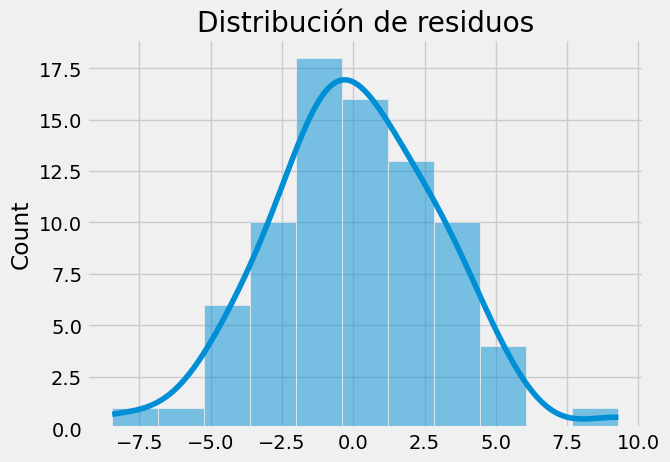

In [87]:
sns.histplot(residuos, kde=True)

plt.title("Distribución de residuos")

plt.show()

El histograma muestra que los residuos siguen una distribución aproximadamente normal (campana de Gauss), en la cual la mayor parte de los errores se concentra alrededor del 0, lo indica que el modelo no tiende a sobreestimar ni subestimar constantemente.

## Paso 13 — Variables significativas

Luego de optimizar el modelo y eliminar las variables redundantes para corregir la multicolinealidad, las variables mas significativas son weight, model_year y origin_usa, ya que todas estas variables presentan p-values de 0.000, lo que indica una relación estadisticamente muy fuerte con el consumo de combustible (mpg).

## Paso 14 — Comparar valores reales y predicciones

In [90]:
comparacion = pd.DataFrame({
    "Real": y_test,
    "Prediccion": y_pred
})

comparacion.head()

,Real,Prediccion
198,33.0,31.860011
396,28.0,29.590835
33,19.0,20.660612
208,13.0,16.902595
93,14.0,12.709549


La tabla muestra que las predicciones estan bastante cerca de la realidad, con una diferencia que suele estar entre 1 y 3 mpg, lo cual es coherente con el error promedio (RMSE de 2.94) que se calculo antes.

El modelo parece funcionar mejor con autos de consumo medio y alto, mientras que en los valores mas bajos tiende a pasarse un poco con la estimacion. Al observar el grafico de "Real vs Prediccion", se nota que el modelo funciona bien en el rango medio porque los puntos estan bien agrupados sobre la linea. En cambio, en la parte baja del grafico, entre 10 y 15 MPG, se ve que varios puntos quedan por encima de la diagonal, lo que indica que el modelo tiende a sobreestimar el rendimiento en esos casos.